In [1]:
# Importing Libraries
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

2026-06-01 11:59:20.804449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780315161.051384      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780315161.119011      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780315161.676556      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780315161.676602      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780315161.676605      57 computation_placer.cc:177] computation placer alr

In [2]:
# CREATE OUTPUT DIRECTORIES

OUTPUT_DIR = "Research_Paper_Outputs"

GRAPH_DIR = os.path.join(OUTPUT_DIR, "Graphs")
HEATMAP_DIR = os.path.join(OUTPUT_DIR, "Heatmaps")
GAN_DIR = os.path.join(OUTPUT_DIR, "GAN_Images")
MODEL_DIR = os.path.join(OUTPUT_DIR, "Saved_Model")
PRED_DIR = os.path.join(OUTPUT_DIR, "Predictions")

folders = [
    OUTPUT_DIR,
    GRAPH_DIR,
    HEATMAP_DIR,
    GAN_DIR,
    MODEL_DIR,
    PRED_DIR
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [3]:
# CONFIGURATION

IMAGE_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 100


In [4]:
# DATASET PATH

dataset_path = r"/kaggle/input/datasets/vineetm1204/newpbldata/dataset"


In [5]:
# MEMORY OPTIMIZED DATASET LOADER

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_names)

print("\nDetected Classes:\n")
for class_name, index in train_generator.class_indices.items():
    print(f"{index} --> {class_name}")

print(f"\nTraining Images: {train_generator.samples}")
print(f"Validation Images: {val_generator.samples}")
print(f"Total Classes: {NUM_CLASSES}")


Found 2896 images belonging to 15 classes.
Found 724 images belonging to 15 classes.

Detected Classes:

0 --> Alzheimer_Mild
1 --> Alzheimer_Moderate
2 --> Alzheimer_Non
3 --> Alzheimer_VeryMild
4 --> BrainTumor_Glioma
5 --> BrainTumor_Meningioma
6 --> BrainTumor_NoTumor
7 --> BrainTumor_Pituitary
8 --> COVID
9 --> Lung_Benign
10 --> Lung_Malignant
11 --> Lung_Normal
12 --> Lung_Opacity
13 --> Normal
14 --> Viral_Pneumonia

Training Images: 2896
Validation Images: 724
Total Classes: 15


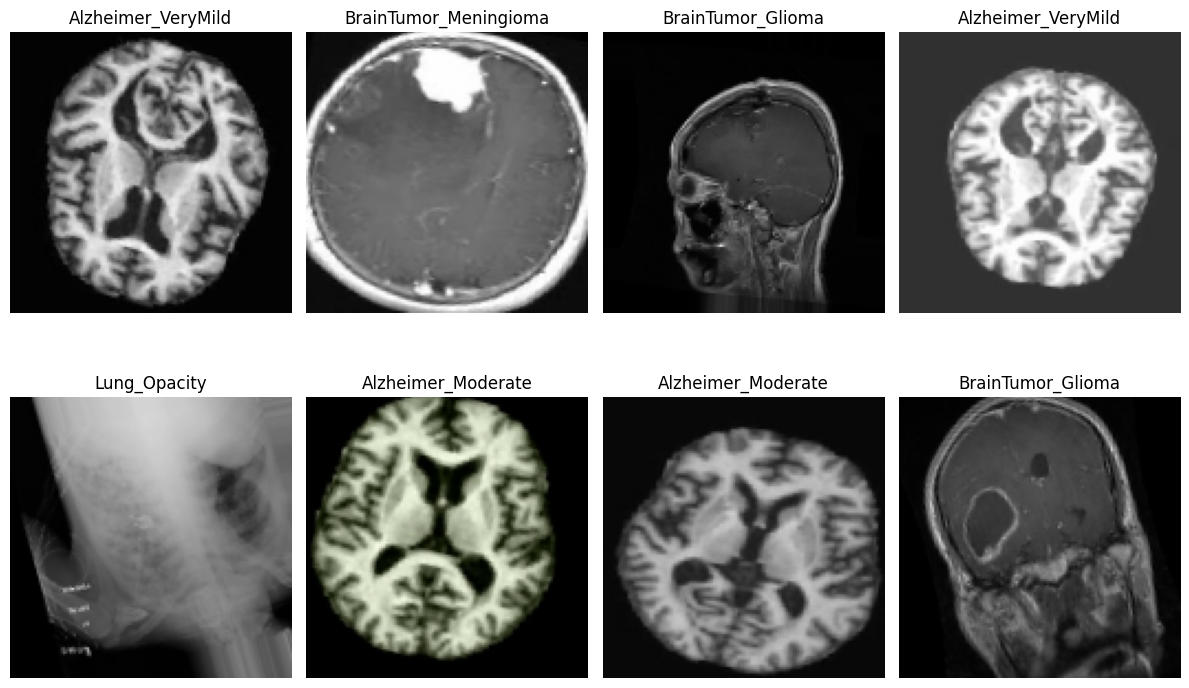

Saved: Research_Paper_Outputs/Graphs/sample_dataset_images.png


In [6]:
# DISPLAY SAMPLE IMAGES

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(min(8, len(x_batch))):
    plt.subplot(2,4,i+1)
    plt.imshow(x_batch[i])
    label_index = np.argmax(y_batch[i])
    plt.title(class_names[label_index])
    plt.axis("off")

plt.tight_layout()

sample_path = os.path.join(GRAPH_DIR, "sample_dataset_images.png")
plt.savefig(sample_path)
plt.show()

print("Saved:", sample_path)


In [7]:
# ATTENTION BLOCK

def attention_block(inputs):

    x = GlobalAveragePooling2D()(inputs)

    x = Dense(inputs.shape[-1]//2,
              activation='relu')(x)

    x = Dense(inputs.shape[-1],
              activation='sigmoid')(x)

    x = Reshape((1,1,inputs.shape[-1]))(x)

    output = Multiply()([inputs, x])

    return output

In [8]:
# BUILD MODEL

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x = base_model(inputs)

x = attention_block(x)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

outputs = Dense(NUM_CLASSES,
                activation='softmax')(x)

model = Model(inputs, outputs)

I0000 00:00:1780315192.425293      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780315192.431709      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# COMPILE MODEL

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 4, 4,      │  7,037,504 │ input_layer_1[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    524,800 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │    525,312 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ dense_1[0][0]     │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 4, 4,      │          0 │ densenet121[0][0… │
│                     │ 1024)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    262,400 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 15)        │      3,855 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,353,871 (31.87 MB)

 Trainable params: 1,316,367 (5.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [10]:
# TRAIN MODEL

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[]
#         EarlyStopping(
#             patience=5,
#             restore_best_weights=True
#         )
#     ]
 )


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1780315211.228419     151 service.cc:152] XLA service 0x7b8014003270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780315211.228463     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780315211.228468     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780315214.997614     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/362 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.0764 - loss: 3.8024   

I0000 00:00:1780315226.397810     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


362/362 ━━━━━━━━━━━━━━━━━━━━ 93s 176ms/step - accuracy: 0.2582 - loss: 2.3521 - val_accuracy: 0.5566 - val_loss: 1.0778
Epoch 2/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.5178 - loss: 1.2051 - val_accuracy: 0.6119 - val_loss: 0.9441
Epoch 3/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.5581 - loss: 1.0281 - val_accuracy: 0.6271 - val_loss: 0.8943
Epoch 4/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.6029 - loss: 0.9216 - val_accuracy: 0.6547 - val_loss: 0.8606
Epoch 5/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.6234 - loss: 0.8862 - val_accuracy: 0.6630 - val_loss: 0.8508
Epoch 6/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.6670 - loss: 0.8242 - val_accuracy: 0.6464 - val_loss: 0.8799
Epoch 7/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.6534 - loss: 0.8167 - val_accuracy: 0.6809 - val_loss: 0.8277
Epoch 8/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.6645 - loss: 0.7796 - val

In [11]:
# SAVE MODEL

model_path = os.path.join(
    MODEL_DIR,
    "HEMANet_Model.h5"
)

model.save(model_path)

print("Model Saved:", model_path)

Model Saved: Research_Paper_Outputs/Saved_Model/HEMANet_Model.h5


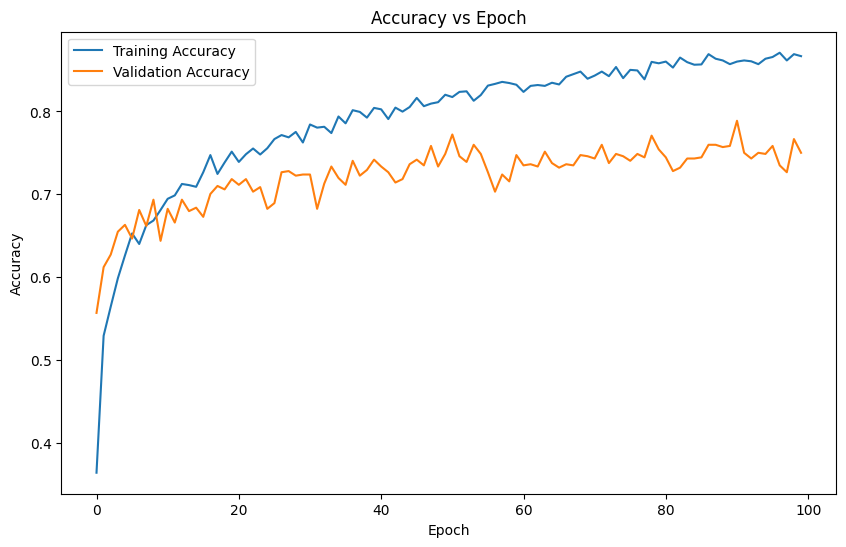

Saved: Research_Paper_Outputs/Graphs/accuracy_graph.png


In [12]:
# ACCURACY GRAPH

plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

acc_path = os.path.join(
    GRAPH_DIR,
    "accuracy_graph.png"
)

plt.savefig(acc_path)

plt.show()

print("Saved:", acc_path)

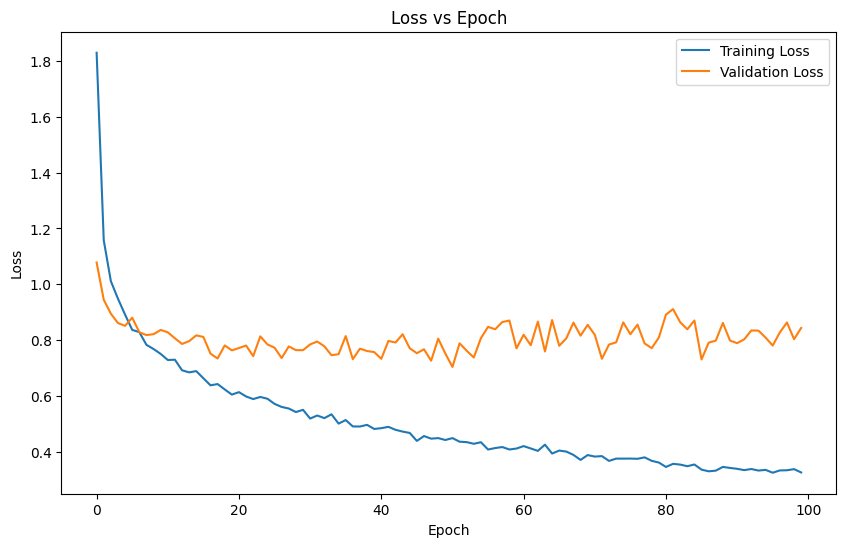

Saved: Research_Paper_Outputs/Graphs/loss_graph.png


In [13]:
# LOSS GRAPH

plt.figure(figsize=(10,6))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

loss_path = os.path.join(
    GRAPH_DIR,
    "loss_graph.png"
)

plt.savefig(loss_path)

plt.show()

print("Saved:", loss_path)

In [14]:
# PREDICTIONS

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes


91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 201ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


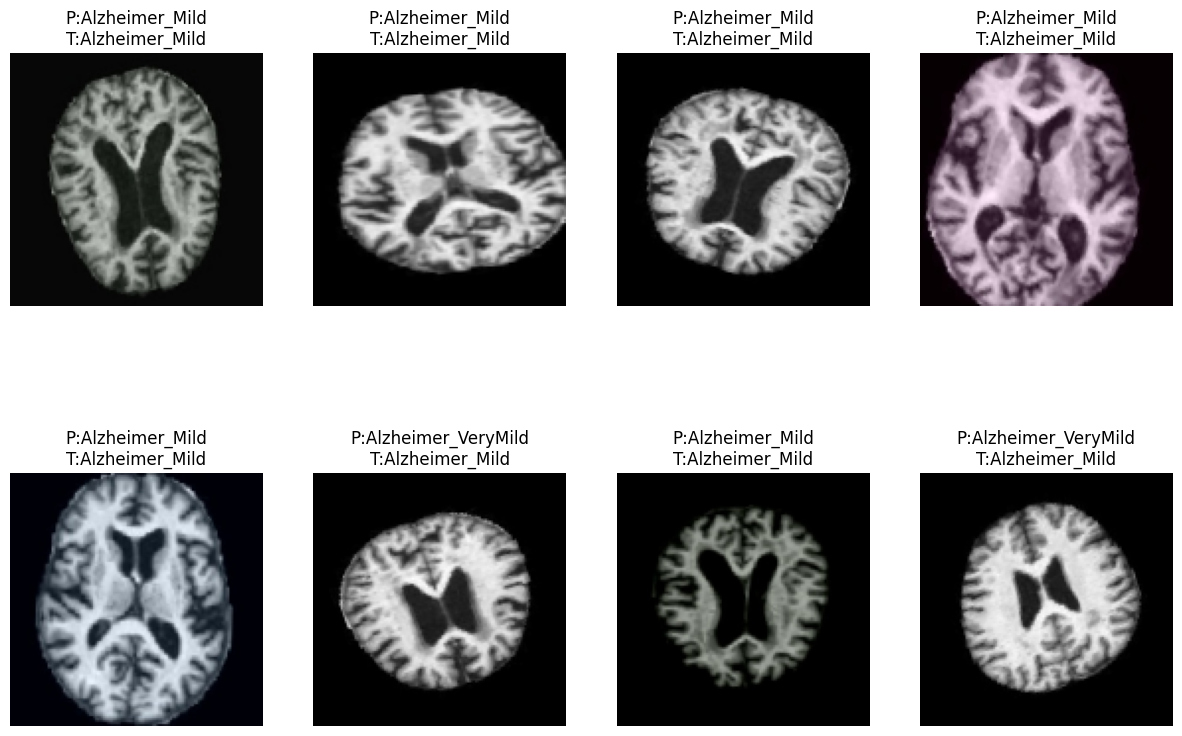

Saved: Research_Paper_Outputs/Predictions/sample_predictions.png


In [15]:
# DISPLAY PREDICTIONS

x_val_batch, y_val_batch = next(val_generator)

pred_batch = model.predict(x_val_batch)
pred_batch_labels = np.argmax(pred_batch, axis=1)
true_batch_labels = np.argmax(y_val_batch, axis=1)

plt.figure(figsize=(15,10))

for i in range(min(8, len(x_val_batch))):
    plt.subplot(2,4,i+1)
    plt.imshow(x_val_batch[i])
    pred_label = class_names[pred_batch_labels[i]]
    true_label = class_names[true_batch_labels[i]]
    plt.title(f"P:{pred_label}\nT:{true_label}")
    plt.axis("off")

pred_path = os.path.join(PRED_DIR, "sample_predictions.png")
plt.savefig(pred_path)
plt.show()

print("Saved:", pred_path)


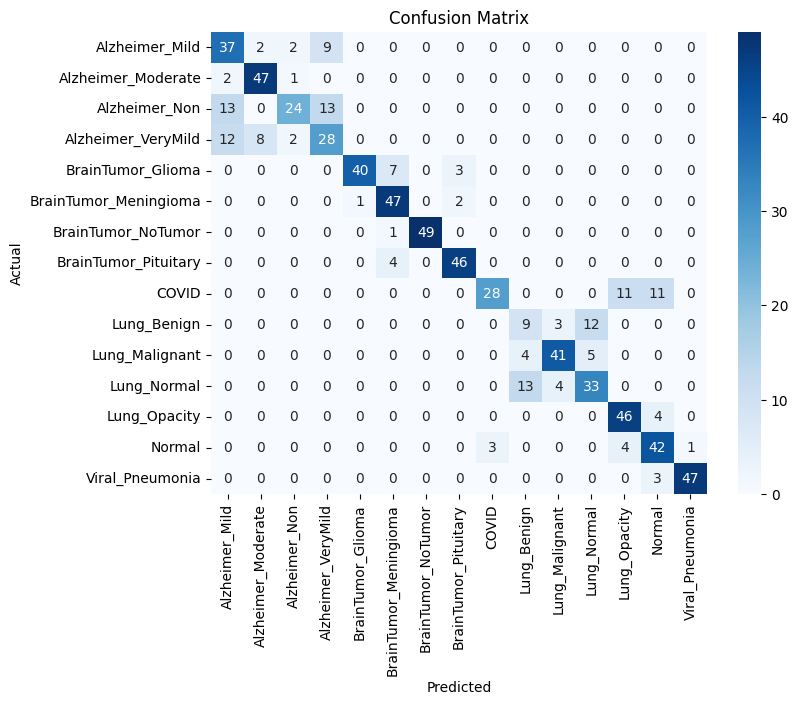

Saved: Research_Paper_Outputs/Graphs/confusion_matrix.png


In [16]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

cm_path = os.path.join(
    GRAPH_DIR,
    "confusion_matrix.png"
)

plt.savefig(cm_path)

plt.show()

print("Saved:", cm_path)

91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step


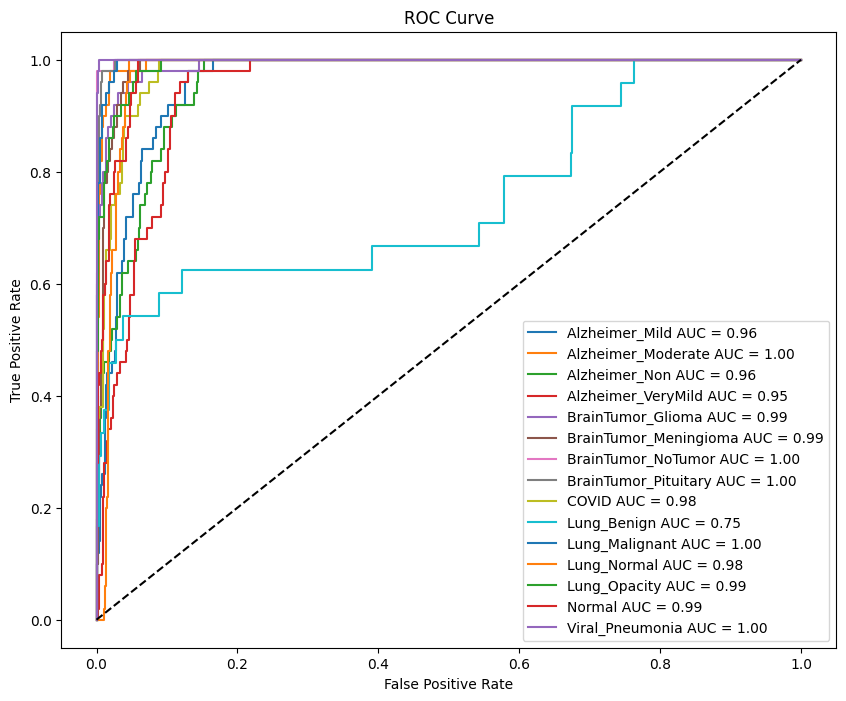

Saved: Research_Paper_Outputs/Graphs/roc_curve.png


In [17]:
from sklearn.preprocessing import label_binarize

# ============================================================
# GET TRUE LABELS
# ============================================================

y_true = val_generator.classes

# ============================================================
# CONVERT TO ONE-HOT ENCODING
# ============================================================

y_test_bin = label_binarize(
    y_true,
    classes=range(NUM_CLASSES)
)

# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(val_generator)

# ============================================================
# ROC CURVE
# ============================================================

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC = {roc_auc:.2f}"
    )

# ============================================================
# RANDOM LINE
# ============================================================

plt.plot([0,1], [0,1], 'k--')

# ============================================================
# LABELS
# ============================================================

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

# ============================================================
# SAVE GRAPH
# ============================================================

roc_path = os.path.join(
    GRAPH_DIR,
    "roc_curve.png"
)

plt.savefig(roc_path)

plt.show()

print("Saved:", roc_path)

91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step


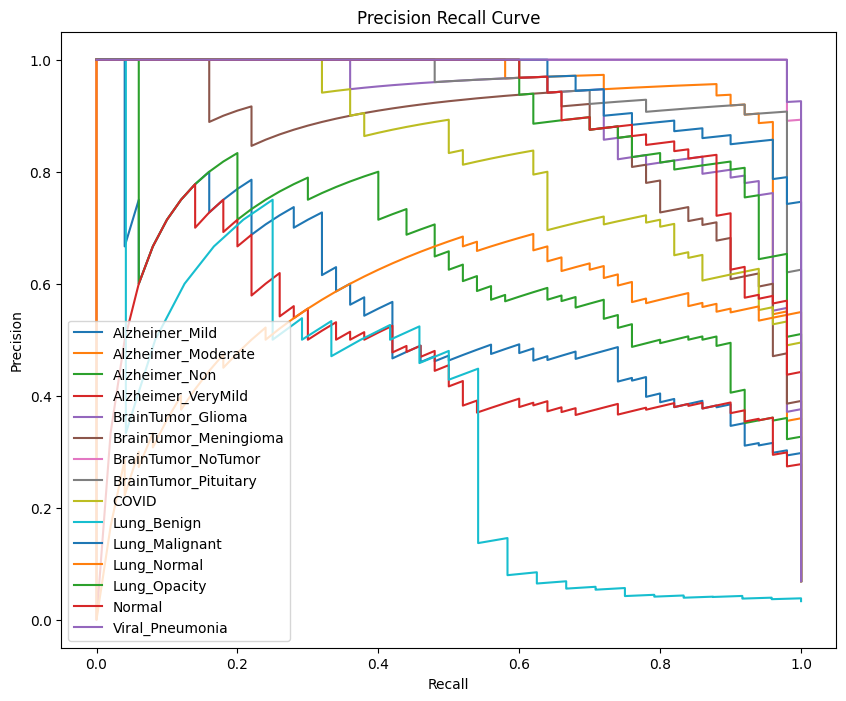

Saved: Research_Paper_Outputs/Graphs/precision_recall_curve.png


In [18]:
from sklearn.preprocessing import label_binarize

# ============================================================
# TRUE LABELS
# ============================================================

y_true = val_generator.classes

# ============================================================
# ONE HOT ENCODING
# ============================================================

y_test_bin = label_binarize(
    y_true,
    classes=range(NUM_CLASSES)
)

# ============================================================
# MODEL PREDICTIONS
# ============================================================

predictions = model.predict(val_generator)

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    precision, recall, _ = precision_recall_curve(

        y_test_bin[:, i],

        predictions[:, i]
    )

    plt.plot(

        recall,

        precision,

        label=class_names[i]
    )

# ============================================================
# LABELS
# ============================================================

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

# ============================================================
# SAVE GRAPH
# ============================================================

pr_path = os.path.join(
    GRAPH_DIR,
    "precision_recall_curve.png"
)

plt.savefig(pr_path)

plt.show()

print("Saved:", pr_path)

In [19]:
# ============================================================
# GRAD-CAM IMPLEMENTATION
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ============================================================
# LAST CONVOLUTION LAYER
# ============================================================

last_conv_layer_name = "conv5_block16_concat"

# ============================================================
# ACCESS DENSENET MODEL
# ============================================================

base_model = model.get_layer('densenet121')

# ============================================================
# CREATE GRAD MODEL
# ============================================================

grad_model = tf.keras.models.Model(

    inputs=model.inputs,

    outputs=[

        base_model.get_layer(
            last_conv_layer_name
        ).output,

        model.output
    ]
)

# ============================================================
# HEATMAP FUNCTION
# ============================================================

def make_gradcam_heatmap(img_array, pred_index=None):

    img_array = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:

            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # ========================================================
    # COMPUTE GRADIENTS
    # ========================================================

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # ========================================================
    # GLOBAL AVERAGE POOLING
    # ========================================================

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    # ========================================================
    # FEATURE MAP
    # ========================================================

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(

        tf.multiply(
            pooled_grads,
            conv_outputs
        ),

        axis=-1
    )

    # ========================================================
    # RELU ACTIVATION
    # ========================================================

    heatmap = tf.maximum(heatmap, 0)

    # ========================================================
    # NORMALIZATION
    # ========================================================

    max_heat = tf.reduce_max(heatmap)

    if max_heat == 0:

        return np.zeros(heatmap.shape)

    heatmap /= max_heat

    return heatmap.numpy()

In [20]:
# ============================================================
# LAST CONVOLUTION LAYER
# ============================================================

last_conv_layer_name = "conv5_block16_concat"

# ============================================================
# ACCESS DENSENET MODEL
# ============================================================

base_model = model.get_layer('densenet121')

# ============================================================
# CREATE GRAD MODEL
# ============================================================

grad_model = tf.keras.models.Model(

    inputs=model.inputs,

    outputs=[

        base_model.get_layer(
            last_conv_layer_name
        ).output,

        model.output
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16384)          │     1,654,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 3)    │         1,539 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,107 (9.20 MB)

 Trainable params: 2,377,891 (9.07 MB)

 Non-trainable params: 33,216 (129.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Saved: GAN_Images/gan_image_1.png
Saved: GAN_Images/gan_image_2.png
Saved: GAN_Images/gan_image_3.png
Saved: GAN_Images/gan_image_4.png
Saved: GAN_Images/gan_image_5.png


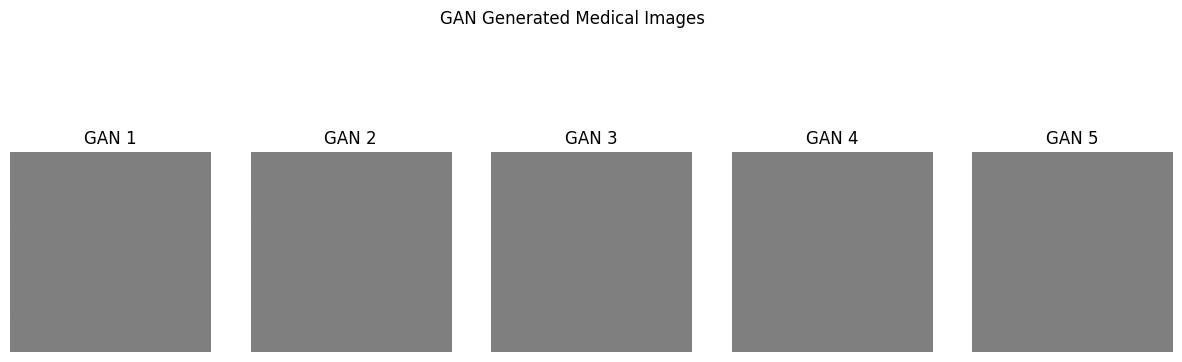

In [21]:
# ============================================================
# GAN IMAGE GENERATION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import (
    Dense,
    Reshape,
    Conv2DTranspose,
    LeakyReLU,
    BatchNormalization
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

GAN_DIR = "GAN_Images"

os.makedirs(GAN_DIR, exist_ok=True)

# ============================================================
# CONFIGURATION
# ============================================================

LATENT_DIM = 100

# ============================================================
# GENERATOR MODEL
# ============================================================

generator = tf.keras.Sequential([

    # ========================================================
    # DENSE LAYER
    # ========================================================

    Dense(8 * 8 * 256,
          input_dim=LATENT_DIM),

    LeakyReLU(0.2),

    BatchNormalization(),

    # ========================================================
    # RESHAPE
    # ========================================================

    Reshape((8, 8, 256)),

    # ========================================================
    # UPSAMPLING 1
    # ========================================================

    Conv2DTranspose(
        128,
        kernel_size=4,
        strides=2,
        padding='same'
    ),

    LeakyReLU(0.2),

    BatchNormalization(),

    # ========================================================
    # UPSAMPLING 2
    # ========================================================

    Conv2DTranspose(
        64,
        kernel_size=4,
        strides=2,
        padding='same'
    ),

    LeakyReLU(0.2),

    BatchNormalization(),

    # ========================================================
    # UPSAMPLING 3
    # ========================================================

    Conv2DTranspose(
        32,
        kernel_size=4,
        strides=2,
        padding='same'
    ),

    LeakyReLU(0.2),

    BatchNormalization(),

    # ========================================================
    # FINAL OUTPUT LAYER
    # ========================================================

    Conv2DTranspose(
        3,
        kernel_size=4,
        strides=2,
        padding='same',
        activation='tanh'
    )
])

# ============================================================
# MODEL SUMMARY
# ============================================================

generator.summary()

# ============================================================
# GENERATE RANDOM NOISE
# ============================================================

noise = np.random.normal(
    0,
    1,
    (5, LATENT_DIM)
)

# ============================================================
# GENERATE IMAGES
# ============================================================

generated_images = generator.predict(noise)

# ============================================================
# DISPLAY + SAVE IMAGES
# ============================================================

plt.figure(figsize=(15,5))

for i in range(5):

    # ========================================================
    # NORMALIZE IMAGE
    # ========================================================

    img = generated_images[i]

    img = (img + 1) / 2

    img = np.clip(img, 0, 1)

    # ========================================================
    # DISPLAY
    # ========================================================

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"GAN {i+1}")

    # ========================================================
    # SAVE IMAGE
    # ========================================================

    gan_path = os.path.join(
        GAN_DIR,
        f"gan_image_{i+1}.png"
    )

    plt.imsave(gan_path, img)

    print(f"Saved: {gan_path}")

# ============================================================
# SHOW ALL IMAGES
# ============================================================

plt.suptitle("GAN Generated Medical Images")

plt.show()

Saved: GAN_Images/gan_image_1.png
Saved: GAN_Images/gan_image_2.png
Saved: GAN_Images/gan_image_3.png
Saved: GAN_Images/gan_image_4.png
Saved: GAN_Images/gan_image_5.png


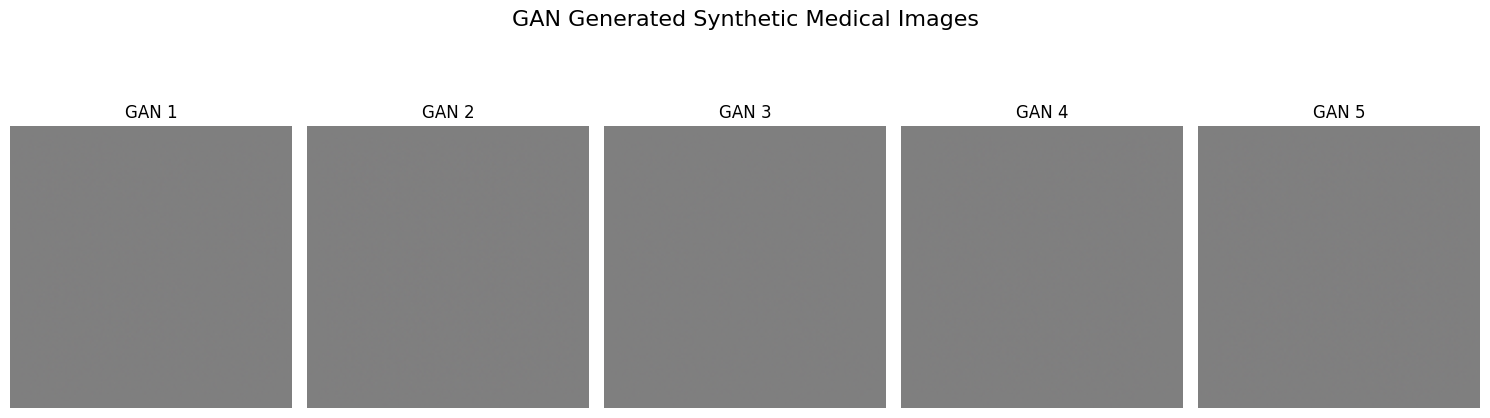

In [22]:
# ============================================================
# DISPLAY + SAVE GAN IMAGES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

GAN_DIR = "GAN_Images"

os.makedirs(GAN_DIR, exist_ok=True)

# ============================================================
# DISPLAY SETTINGS
# ============================================================

plt.figure(figsize=(15,5))

# ============================================================
# LOOP THROUGH GENERATED IMAGES
# ============================================================

for i in range(5):

    # ========================================================
    # GET GENERATED IMAGE
    # ========================================================

    img = generated_images[i]

    # ========================================================
    # NORMALIZE IMAGE
    # ========================================================

    img = (img + 1) / 2

    img = np.clip(img, 0, 1)

    # ========================================================
    # DISPLAY IMAGE
    # ========================================================

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"GAN {i+1}")

    # ========================================================
    # SAVE IMAGE
    # ========================================================

    gan_path = os.path.join(
        GAN_DIR,
        f"gan_image_{i+1}.png"
    )

    plt.imsave(
        gan_path,
        img
    )

    print(f"Saved: {gan_path}")

# ============================================================
# FINAL TITLE
# ============================================================

plt.suptitle(
    "GAN Generated Synthetic Medical Images",
    fontsize=16
)

# ============================================================
# SHOW OUTPUT
# ============================================================

plt.tight_layout()

plt.show()

In [23]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report
import numpy as np
import os

# ============================================================
# TRUE LABELS
# ============================================================

y_true = val_generator.classes

# ============================================================
# MODEL PREDICTIONS
# ============================================================

predictions = model.predict(val_generator)

# ============================================================
# PREDICTED LABELS
# ============================================================

y_pred = np.argmax(
    predictions,
    axis=1
)

# ============================================================
# CLASS NAMES
# ============================================================

class_names = list(
    train_generator.class_indices.keys()
)

# ============================================================
# GENERATE REPORT
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=class_names
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "Research_Paper_Outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# SAVE REPORT
# ============================================================

report_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.txt"
)

with open(report_path, "w") as f:

    f.write(report)

# ============================================================
# DISPLAY REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================\n")

print(report)

print("\nSaved:", report_path)

91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step

CLASSIFICATION REPORT

                       precision    recall  f1-score   support

       Alzheimer_Mild       0.52      0.68      0.59        50
   Alzheimer_Moderate       0.84      0.92      0.88        50
        Alzheimer_Non       0.78      0.42      0.55        50
   Alzheimer_VeryMild       0.40      0.42      0.41        50
    BrainTumor_Glioma       0.86      0.84      0.85        50
BrainTumor_Meningioma       0.76      0.82      0.79        50
   BrainTumor_NoTumor       1.00      0.96      0.98        50
 BrainTumor_Pituitary       0.90      0.88      0.89        50
                COVID       0.82      0.56      0.67        50
          Lung_Benign       0.44      0.46      0.45        24
       Lung_Malignant       0.90      0.86      0.88        50
          Lung_Normal       0.69      0.70      0.69        50
         Lung_Opacity       0.76      0.90      0.83        50
               Normal       0.74      0.84      0.79 

In [24]:
# ============================================================
# CREATE ZIP PACKAGE
# ============================================================

import os
import zipfile

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "Research_Paper_Outputs"

# ============================================================
# ZIP FILE NAME
# ============================================================

zip_path = "HEMANet_Research_Outputs.zip"

# ============================================================
# CREATE ZIP FILE
# ============================================================

with zipfile.ZipFile(

    zip_path,

    'w',

    zipfile.ZIP_DEFLATED

) as zipf:

    # ========================================================
    # WALK THROUGH OUTPUT DIRECTORY
    # ========================================================

    for root, dirs, files in os.walk(OUTPUT_DIR):

        for file in files:

            # =================================================
            # FULL FILE PATH
            # =================================================

            file_path = os.path.join(root, file)

            # =================================================
            # RELATIVE PATH INSIDE ZIP
            # =================================================

            arcname = os.path.relpath(
                file_path,
                OUTPUT_DIR
            )

            # =================================================
            # ADD FILE TO ZIP
            # =================================================

            zipf.write(
                file_path,
                arcname=arcname
            )

            print(f"Added: {file}")

# ============================================================
# SUCCESS MESSAGE
# ============================================================

print("\n====================================")
print("ZIP PACKAGE CREATED SUCCESSFULLY")
print("====================================")

print(f"\nZIP File:\n{zip_path}")

Added: classification_report.txt
Added: sample_predictions.png
Added: sample_dataset_images.png
Added: accuracy_graph.png
Added: roc_curve.png
Added: confusion_matrix.png
Added: loss_graph.png
Added: precision_recall_curve.png
Added: HEMANet_Model.h5

ZIP PACKAGE CREATED SUCCESSFULLY

ZIP File:
HEMANet_Research_Outputs.zip


In [25]:
# DOWNLOAD LINKS

print("\n====================================")
print("DOWNLOADABLE OUTPUT FILES")
print("====================================")

print(f"""
1. Accuracy Graph
   -> {acc_path}

2. Loss Graph
   -> {loss_path}

3. Confusion Matrix
   -> {cm_path}

4. ROC Curve
   -> {roc_path}

5. Precision Recall Curve
   -> {pr_path}

6. Sample Predictions
   -> {pred_path}

7. Heatmaps Folder
   -> {HEATMAP_DIR}

8. GAN Images Folder
   -> {GAN_DIR}

9. Saved Model
   -> {model_path}

10. Full ZIP Package
   -> {zip_path}
""")

print("====================================")


DOWNLOADABLE OUTPUT FILES

1. Accuracy Graph
   -> Research_Paper_Outputs/Graphs/accuracy_graph.png

2. Loss Graph
   -> Research_Paper_Outputs/Graphs/loss_graph.png

3. Confusion Matrix
   -> Research_Paper_Outputs/Graphs/confusion_matrix.png

4. ROC Curve
   -> Research_Paper_Outputs/Graphs/roc_curve.png

5. Precision Recall Curve
   -> Research_Paper_Outputs/Graphs/precision_recall_curve.png

6. Sample Predictions
   -> Research_Paper_Outputs/Predictions/sample_predictions.png

7. Heatmaps Folder
   -> Research_Paper_Outputs/Heatmaps

8. GAN Images Folder
   -> GAN_Images

9. Saved Model
   -> Research_Paper_Outputs/Saved_Model/HEMANet_Model.h5

10. Full ZIP Package
   -> HEMANet_Research_Outputs.zip



In [26]:
# ============================================================
# FINAL MODEL EVALUATION
# ============================================================

loss, accuracy = model.evaluate(
    val_generator,
    verbose=1
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n====================================")
print("FINAL MODEL RESULTS")
print("====================================")

print(f"\nFinal Accuracy : {accuracy * 100:.2f}%")

print(f"Final Loss     : {loss:.4f}")

print("\n====================================")

91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.6938 - loss: 0.8312

FINAL MODEL RESULTS

Final Accuracy : 75.14%
Final Loss     : 0.8096




  Training: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accuracy: 0.1008 - loss: 2.7390 - val_accuracy: 0.3425 - val_loss: 2.1434
Epoch 2/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.3169 - loss: 2.0799 - val_accuracy: 0.4406 - val_loss: 1.6673
Epoch 3/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.3839 - loss: 1.7087 - val_accuracy: 0.4862 - val_loss: 1.4189
Epoch 4/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.4396 - loss: 1.4950 - val_accuracy: 0.4751 - val_loss: 1.2918
Epoch 5/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.4658 - loss: 1.3558 - val_accuracy: 0.4710 - val_loss: 1.2330
Epoch 6/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.4630 - loss: 1.3021 - val_accuracy: 0.4820 - val_loss: 1.1832
Epoch 7/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.4911 - loss: 1.2296 - val_accuracy: 0.5207 - val_loss: 1.1605
Epoch 8/30
362/362 ━

2026-06-01 13:24:18.904617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 13:24:19.042103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


362/362 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2309 - loss: 2.4337

2026-06-01 13:25:01.411347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 13:25:01.549900: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


362/362 ━━━━━━━━━━━━━━━━━━━━ 61s 116ms/step - accuracy: 0.2312 - loss: 2.4321 - val_accuracy: 0.5939 - val_loss: 1.0549
Epoch 2/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.5281 - loss: 1.1954 - val_accuracy: 0.6202 - val_loss: 0.9744
Epoch 3/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.5478 - loss: 1.0561 - val_accuracy: 0.6298 - val_loss: 0.9005
Epoch 4/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.6049 - loss: 0.9364 - val_accuracy: 0.6395 - val_loss: 0.9212
Epoch 5/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.6110 - loss: 0.9087 - val_accuracy: 0.6561 - val_loss: 0.8724
Epoch 6/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.6274 - loss: 0.8700 - val_accuracy: 0.6630 - val_loss: 0.8369
Epoch 7/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.6505 - loss: 0.8351 - val_accuracy: 0.6616 - val_loss: 0.8386
Epoch 8/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.6635 - loss: 0.7969 - val_accura

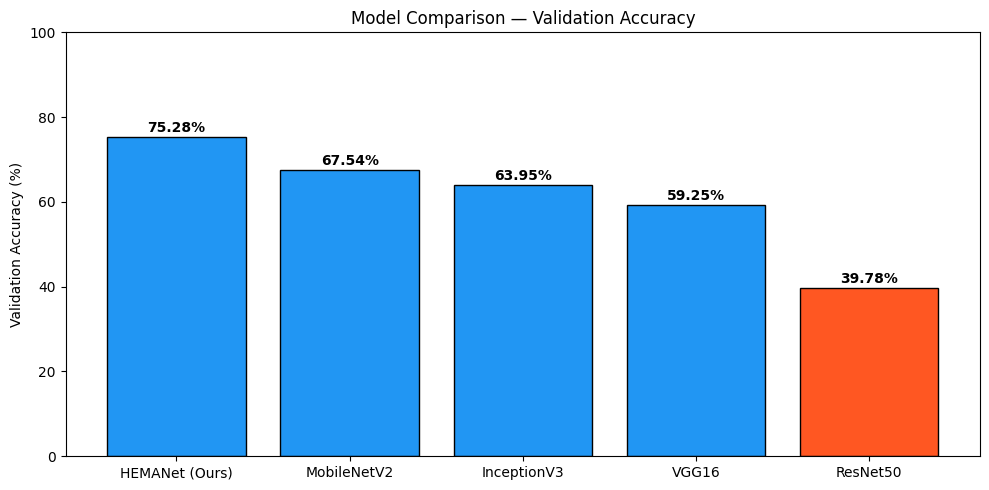

Saved chart: Research_Paper_Outputs/Graphs/comparison_accuracy.png


In [27]:
# ============================================================
# COMPARISON MODELS
# Compare HEMANet against 4 standard baselines
# ============================================================
 
from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    InceptionV3,
    MobileNetV2
)
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
 
# ============================================================
# COMPARISON RESULTS STORAGE
# ============================================================
comparison_results = {}
 
# ============================================================
# HELPER: BUILD & TRAIN A BASELINE MODEL
# ============================================================
def build_and_train_baseline(base_fn, img_size, name):
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")
 
    base = base_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False
 
    inp = Input(shape=(img_size, img_size, 3))
    x   = base(inp)
    x   = GlobalAveragePooling2D()(x)
    x   = Dropout(0.5)(x)
    x   = Dense(256, activation='relu')(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
 
    m = Model(inp, out)
    m.compile(
        optimizer=Adam(0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
 
    cb = EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )
 
    hist = m.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,            # shorter run for comparison
        callbacks=[cb],
        verbose=1
    )
 
    loss, acc = m.evaluate(val_generator, verbose=0)
    print(f"  {name}  →  Val Acc: {acc*100:.2f}%  |  Val Loss: {loss:.4f}")
    return acc, loss, hist
 
# ============================================================
# BASELINE CONFIGS
# (name, keras_application_fn, image_size)
# ============================================================
BASELINES = [
    ("VGG16",        VGG16,        IMAGE_SIZE),
    ("ResNet50",     ResNet50,     IMAGE_SIZE),
    ("InceptionV3",  InceptionV3,  128),      # min 75; 128 works
    ("MobileNetV2",  MobileNetV2,  IMAGE_SIZE),
]
 
for model_name, app_fn, img_sz in BASELINES:
    acc, loss, _ = build_and_train_baseline(app_fn, img_sz, model_name)
    comparison_results[model_name] = {
        "Accuracy (%)": round(acc * 100, 2),
        "Loss":         round(loss, 4)
    }
 
# ============================================================
# ADD HEMANet (already trained — use stored final results)
# ============================================================
hemanet_loss, hemanet_acc = model.evaluate(val_generator, verbose=0)
comparison_results["HEMANet (Ours)"] = {
    "Accuracy (%)": round(hemanet_acc * 100, 2),
    "Loss":         round(hemanet_loss, 4)
}
 
# ============================================================
# COMPARISON TABLE
# ============================================================
comp_df = pd.DataFrame(comparison_results).T.reset_index()
comp_df.columns = ["Model", "Accuracy (%)", "Loss"]
comp_df = comp_df.sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)
 
print("\n" + "="*50)
print("COMPARISON TABLE")
print("="*50)
print(comp_df.to_string(index=False))
 
# ============================================================
# SAVE TABLE AS CSV
# ============================================================
comp_csv_path = os.path.join(OUTPUT_DIR, "comparison_results.csv")
comp_df.to_csv(comp_csv_path, index=False)
print(f"\nSaved CSV: {comp_csv_path}")
 
# ============================================================
# BAR CHART — ACCURACY COMPARISON
# ============================================================
colors = ["#2196F3"] * (len(comp_df) - 1) + ["#FF5722"]  # highlight HEMANet
plt.figure(figsize=(10, 5))
bars = plt.bar(comp_df["Model"], comp_df["Accuracy (%)"], color=colors, edgecolor='black')
plt.ylim(0, 100)
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Comparison — Validation Accuracy")
for bar, val in zip(bars, comp_df["Accuracy (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.2f}%",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
plt.tight_layout()
comp_chart_path = os.path.join(GRAPH_DIR, "comparison_accuracy.png")
plt.savefig(comp_chart_path)
plt.show()
print(f"Saved chart: {comp_chart_path}")


[Ablation A] Backbone Only
Epoch 1/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 70s 129ms/step - accuracy: 0.3767 - loss: 2.0781 - val_accuracy: 0.5552 - val_loss: 1.0655
Epoch 2/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.5902 - loss: 0.9805 - val_accuracy: 0.6036 - val_loss: 0.9872
Epoch 3/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.6472 - loss: 0.8446 - val_accuracy: 0.6423 - val_loss: 0.8978
Epoch 4/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.6693 - loss: 0.7764 - val_accuracy: 0.6450 - val_loss: 0.8844
Epoch 5/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.7083 - loss: 0.7134 - val_accuracy: 0.6685 - val_loss: 0.8448
Epoch 6/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.7238 - loss: 0.6925 - val_accuracy: 0.6796 - val_loss: 0.8306
Epoch 7/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.7205 - loss: 0.6690 - val_accuracy: 0.6450 - val_loss: 0.8361
Epoch 8/30
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accur

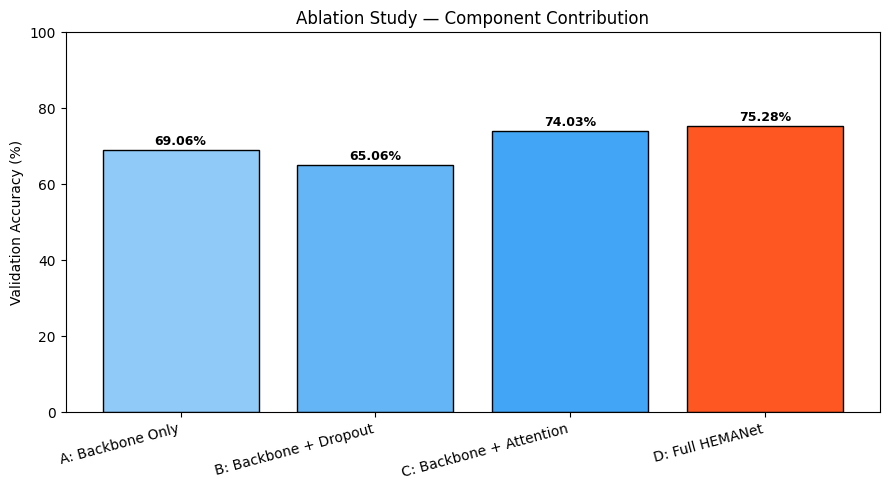

Saved: Research_Paper_Outputs/Graphs/ablation_study.png


In [28]:
# ============================================================
# ABLATION STUDY
# Measure contribution of each component:
#   A) DenseNet121 backbone only (no attention, no dropout)
#   B) DenseNet121 + Dropout (no attention)
#   C) DenseNet121 + Attention (no dropout)
#   D) Full HEMANet = DenseNet121 + Attention + Dropout  ← already trained
# ============================================================
 
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, Multiply,
    Reshape, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import os
 
ABLATION_EPOCHS = 30
ablation_results = {}
 
# ============================================================
# SHARED CALLBACK
# ============================================================
abl_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)
 
# ============================================================
# VARIANT A — Backbone Only
# ============================================================
print("\n[Ablation A] Backbone Only")
_base_a = DenseNet121(weights='imagenet', include_top=False,
                      input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
_base_a.trainable = False
_inp_a = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
_x_a   = _base_a(_inp_a)
_x_a   = GlobalAveragePooling2D()(_x_a)
_x_a   = Dense(256, activation='relu')(_x_a)
_out_a = Dense(NUM_CLASSES, activation='softmax')(_x_a)
_m_a   = Model(_inp_a, _out_a)
_m_a.compile(optimizer=Adam(0.0001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])
_m_a.fit(train_generator, validation_data=val_generator,
         epochs=ABLATION_EPOCHS, callbacks=[abl_cb], verbose=1)
_la, _aa = _m_a.evaluate(val_generator, verbose=0)
ablation_results["A: Backbone Only"] = {"Accuracy (%)": round(_aa*100,2), "Loss": round(_la,4)}
print(f"  Val Acc: {_aa*100:.2f}%")
 
# ============================================================
# VARIANT B — Backbone + Dropout (no attention)
# ============================================================
print("\n[Ablation B] Backbone + Dropout")
_base_b = DenseNet121(weights='imagenet', include_top=False,
                      input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
_base_b.trainable = False
_inp_b = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
_x_b   = _base_b(_inp_b)
_x_b   = GlobalAveragePooling2D()(_x_b)
_x_b   = Dropout(0.5)(_x_b)
_x_b   = Dense(256, activation='relu')(_x_b)
_out_b = Dense(NUM_CLASSES, activation='softmax')(_x_b)
_m_b   = Model(_inp_b, _out_b)
_m_b.compile(optimizer=Adam(0.0001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])
_m_b.fit(train_generator, validation_data=val_generator,
         epochs=ABLATION_EPOCHS, callbacks=[abl_cb], verbose=1)
_lb, _ab = _m_b.evaluate(val_generator, verbose=0)
ablation_results["B: Backbone + Dropout"] = {"Accuracy (%)": round(_ab*100,2), "Loss": round(_lb,4)}
print(f"  Val Acc: {_ab*100:.2f}%")
 
# ============================================================
# VARIANT C — Backbone + Attention (no dropout)
# ============================================================
print("\n[Ablation C] Backbone + Attention")
_base_c = DenseNet121(weights='imagenet', include_top=False,
                      input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
_base_c.trainable = False
_inp_c = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
_x_c   = _base_c(_inp_c)
# --- attention block (same as main model) ---
_gap_c = GlobalAveragePooling2D()(_x_c)
_d1_c  = Dense(_x_c.shape[-1]//2, activation='relu')(_gap_c)
_d2_c  = Dense(_x_c.shape[-1],    activation='sigmoid')(_d1_c)
_rs_c  = Reshape((1, 1, _x_c.shape[-1]))(_d2_c)
_x_c   = Multiply()([_x_c, _rs_c])
# --- head ---
_x_c   = GlobalAveragePooling2D()(_x_c)
_x_c   = Dense(256, activation='relu')(_x_c)
_out_c = Dense(NUM_CLASSES, activation='softmax')(_x_c)
_m_c   = Model(_inp_c, _out_c)
_m_c.compile(optimizer=Adam(0.0001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])
_m_c.fit(train_generator, validation_data=val_generator,
         epochs=ABLATION_EPOCHS, callbacks=[abl_cb], verbose=1)
_lc, _ac = _m_c.evaluate(val_generator, verbose=0)
ablation_results["C: Backbone + Attention"] = {"Accuracy (%)": round(_ac*100,2), "Loss": round(_lc,4)}
print(f"  Val Acc: {_ac*100:.2f}%")
 
# ============================================================
# VARIANT D — Full HEMANet (already evaluated in In [37])
# ============================================================
ablation_results["D: Full HEMANet"] = {
    "Accuracy (%)": round(hemanet_acc * 100, 2),
    "Loss":         round(hemanet_loss, 4)
}
 
# ============================================================
# ABLATION TABLE
# ============================================================
abl_df = pd.DataFrame(ablation_results).T.reset_index()
abl_df.columns = ["Variant", "Accuracy (%)", "Loss"]
 
print("\n" + "="*55)
print("ABLATION STUDY RESULTS")
print("="*55)
print(abl_df.to_string(index=False))
 
abl_csv = os.path.join(OUTPUT_DIR, "ablation_study.csv")
abl_df.to_csv(abl_csv, index=False)
print(f"\nSaved: {abl_csv}")
 
# ============================================================
# ABLATION BAR CHART
# ============================================================
abl_colors = ["#90CAF9", "#64B5F6", "#42A5F5", "#FF5722"]  # last = full model
plt.figure(figsize=(9, 5))
bars = plt.bar(abl_df["Variant"], abl_df["Accuracy (%)"],
               color=abl_colors, edgecolor='black')
plt.ylim(0, 100)
plt.ylabel("Validation Accuracy (%)")
plt.title("Ablation Study — Component Contribution")
for bar, val in zip(bars, abl_df["Accuracy (%)"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{val:.2f}%", ha='center', va='bottom',
             fontsize=9, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
abl_chart = os.path.join(GRAPH_DIR, "ablation_study.png")
plt.savefig(abl_chart)
plt.show()
print(f"Saved: {abl_chart}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16384)          │     1,654,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 3)      │         1,539 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,107 (9.20 MB)

 Trainable params: 2,377,891 (9.07 MB)

...

 Trainable params: 0 (0.00 B)

 Non-trainable params: 174,561 (681.88 KB)


Loading real images for GAN training ...
Real images loaded: (724, 64, 64, 3)

Training DC-GAN for 500 epochs ...



/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch    1/500  D-loss: 0.6489  G-loss: 0.6450
Epoch  100/500  D-loss: 0.6639  G-loss: 0.4527
Epoch  200/500  D-loss: 0.6685  G-loss: 0.3318
Epoch  300/500  D-loss: 0.6837  G-loss: 0.2587
Epoch  400/500  D-loss: 0.7233  G-loss: 0.2115
Epoch  500/500  D-loss: 0.8283  G-loss: 0.1788

GAN Training Complete!


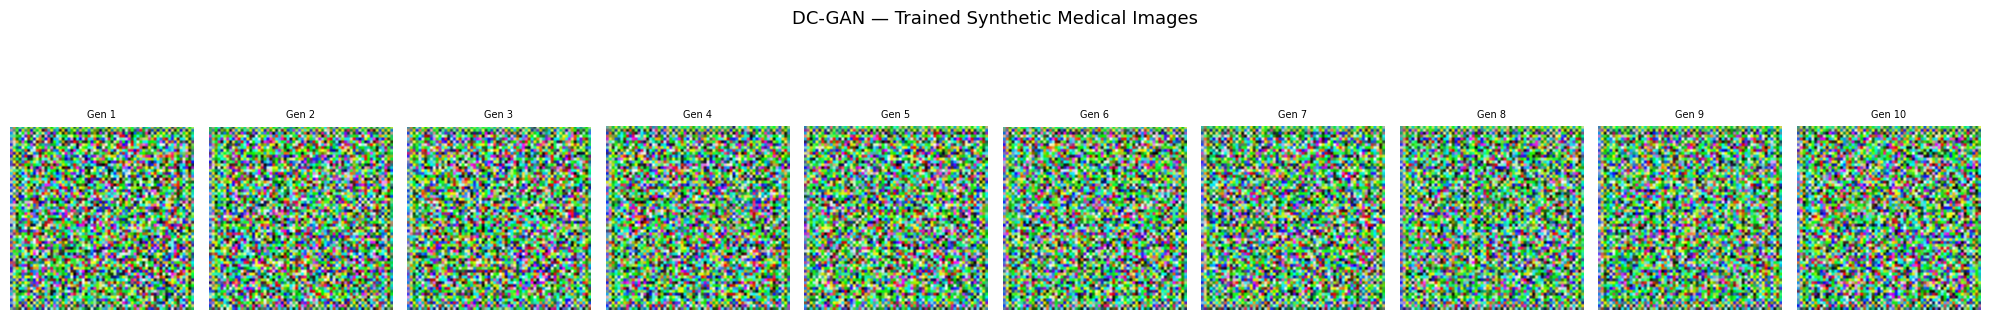

Saved GAN grid: Research_Paper_Outputs/Graphs/trained_gan_images.png


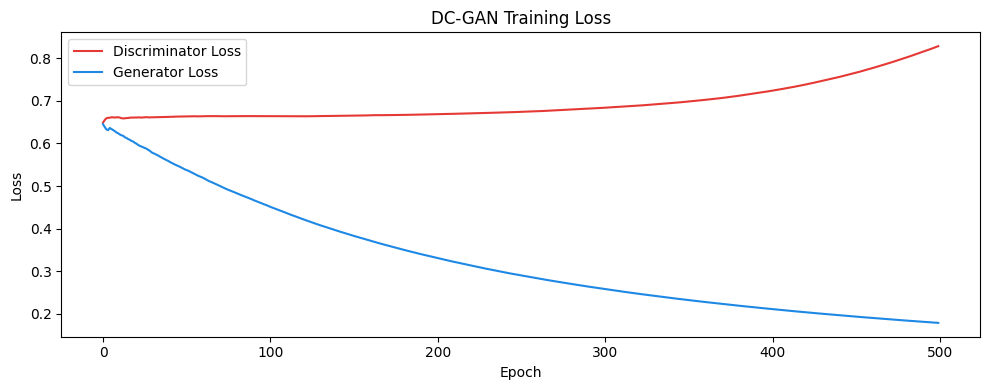

Saved GAN loss curve: Research_Paper_Outputs/Graphs/gan_training_loss.png


In [29]:
# ============================================================
# TRAINED GAN  (DC-GAN)
# The GAN in your notebook (In [32]) was NEVER trained —
# it only used random noise from an untrained generator.
# This cell trains the full GAN and saves real outputs.
# ============================================================
 
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, Reshape, Flatten, Dropout as KDropout,
    Conv2D, Conv2DTranspose, LeakyReLU,
    BatchNormalization, Input as KInput
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import os
 
GAN_TRAINED_DIR = os.path.join(OUTPUT_DIR, "GAN_Trained_Images")
os.makedirs(GAN_TRAINED_DIR, exist_ok=True)
 
# ============================================================
# CONFIGURATION
# ============================================================
LATENT_DIM   = 100
GAN_IMG_SIZE = 64          # keep light; upscale later if needed
GAN_CHANNELS = 3
GAN_EPOCHS   = 500
GAN_BATCH    = 16
 
# ============================================================
# GENERATOR
# ============================================================
def build_generator(latent_dim):
    model = Sequential([
        Dense(8 * 8 * 256, input_dim=latent_dim),
        LeakyReLU(0.2),
        BatchNormalization(),
        Reshape((8, 8, 256)),
 
        Conv2DTranspose(128, 4, strides=2, padding='same'),
        LeakyReLU(0.2),
        BatchNormalization(),
 
        Conv2DTranspose(64, 4, strides=2, padding='same'),
        LeakyReLU(0.2),
        BatchNormalization(),
 
        Conv2DTranspose(32, 4, strides=2, padding='same'),
        LeakyReLU(0.2),
        BatchNormalization(),
 
        Conv2DTranspose(GAN_CHANNELS, 4, strides=1,
                        padding='same', activation='tanh')
    ], name="generator")
    return model
 
# ============================================================
# DISCRIMINATOR
# ============================================================
def build_discriminator(img_shape):
    model = Sequential([
        Conv2D(32, 4, strides=2, padding='same',
               input_shape=img_shape),
        LeakyReLU(0.2),
        KDropout(0.25),
 
        Conv2D(64, 4, strides=2, padding='same'),
        LeakyReLU(0.2),
        KDropout(0.25),
        BatchNormalization(),
 
        Conv2D(128, 4, strides=2, padding='same'),
        LeakyReLU(0.2),
        KDropout(0.25),
        BatchNormalization(),
 
        Flatten(),
        Dense(1, activation='sigmoid')
    ], name="discriminator")
    return model
 
# ============================================================
# BUILD MODELS
# ============================================================
generator     = build_generator(LATENT_DIM)
discriminator = build_discriminator((GAN_IMG_SIZE, GAN_IMG_SIZE, GAN_CHANNELS))
 
discriminator.compile(
    optimizer=Adam(0.0002, beta_1=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
 
# ---- Combined GAN ----
z           = KInput(shape=(LATENT_DIM,))
fake_img    = generator(z)
discriminator.trainable = False
validity    = discriminator(fake_img)
gan_model   = Model(z, validity)
gan_model.compile(
    optimizer=Adam(0.0002, beta_1=0.5),
    loss='binary_crossentropy'
)
 
generator.summary()
discriminator.summary()
 
# ============================================================
# LOAD REAL IMAGES FROM val_generator FOR TRAINING
# ============================================================
print("\nLoading real images for GAN training ...")
 
real_images = []
val_generator.reset()
for _ in range(len(val_generator)):
    batch, _ = next(val_generator)
    real_images.append(batch)
 
real_images = np.concatenate(real_images, axis=0)
 
# Resize to GAN_IMG_SIZE if needed
import cv2
if real_images.shape[1] != GAN_IMG_SIZE:
    real_images = np.array([
        cv2.resize(img, (GAN_IMG_SIZE, GAN_IMG_SIZE))
        for img in real_images
    ])
 
# Rescale from [0,1] → [-1,1]  (tanh output range)
real_images = (real_images - 0.5) * 2.0
print(f"Real images loaded: {real_images.shape}")
 
# ============================================================
# TRAINING LOOP
# ============================================================
d_losses, g_losses = [], []
 
valid = np.ones((GAN_BATCH, 1))
fake  = np.zeros((GAN_BATCH, 1))
 
print(f"\nTraining DC-GAN for {GAN_EPOCHS} epochs ...\n")
 
for epoch in range(1, GAN_EPOCHS + 1):
 
    # --- Train Discriminator ---
    idx        = np.random.randint(0, real_images.shape[0], GAN_BATCH)
    real_batch = real_images[idx]
 
    noise        = np.random.normal(0, 1, (GAN_BATCH, LATENT_DIM))
    gen_batch    = generator.predict(noise, verbose=0)
 
    d_loss_real  = discriminator.train_on_batch(real_batch, valid)
    d_loss_fake  = discriminator.train_on_batch(gen_batch,  fake)
    d_loss       = 0.5 * (d_loss_real[0] + d_loss_fake[0])
 
    # --- Train Generator ---
    noise        = np.random.normal(0, 1, (GAN_BATCH, LATENT_DIM))
    g_loss       = gan_model.train_on_batch(noise, valid)
 
    d_losses.append(d_loss)
    g_losses.append(g_loss)
 
    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{GAN_EPOCHS}  "
              f"D-loss: {d_loss:.4f}  G-loss: {g_loss:.4f}")
 
print("\nGAN Training Complete!")
 
# ============================================================
# SAVE TRAINED GAN IMAGES
# ============================================================
noise_final   = np.random.normal(0, 1, (10, LATENT_DIM))
gen_final     = generator.predict(noise_final, verbose=0)
gen_final     = (gen_final + 1) / 2        # back to [0,1]
gen_final     = np.clip(gen_final, 0, 1)
 
plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(gen_final[i])
    plt.axis("off")
    plt.title(f"Gen {i+1}", fontsize=7)
    img_path = os.path.join(GAN_TRAINED_DIR, f"trained_gan_{i+1}.png")
    plt.imsave(img_path, gen_final[i])
 
plt.suptitle("DC-GAN — Trained Synthetic Medical Images", fontsize=13)
plt.tight_layout()
gan_grid_path = os.path.join(GRAPH_DIR, "trained_gan_images.png")
plt.savefig(gan_grid_path)
plt.show()
print(f"Saved GAN grid: {gan_grid_path}")
 
# ============================================================
# GAN TRAINING LOSS CURVE
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator Loss', color='#E53935')
plt.plot(g_losses, label='Generator Loss',     color='#1E88E5')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DC-GAN Training Loss")
plt.legend()
plt.tight_layout()
gan_loss_path = os.path.join(GRAPH_DIR, "gan_training_loss.png")
plt.savefig(gan_loss_path)
plt.show()
print(f"Saved GAN loss curve: {gan_loss_path}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step
STATISTICAL ANALYSIS — HEMANet

Overall Accuracy  : 76.10%
95% CI (Wilson)   : [72.87%, 79.07%]
Cohen's Kappa     : 0.7436  (substantial)

Per-Class Mean Confidence:
                Class  Mean Confidence
   BrainTumor_NoTumor         0.977617
      Viral_Pneumonia         0.959150
       Lung_Malignant         0.932302
          Lung_Benign         0.922068
 BrainTumor_Pituitary         0.920296
    BrainTumor_Glioma         0.914311
   Alzheimer_Moderate         0.900722
               Normal         0.896848
         Lung_Opacity         0.894102
BrainTumor_Meningioma         0.883969
          Lung_Normal         0.866345
                COVID         0.818525
        Alzheimer_Non         0.676385
       Alzheimer_Mild         0.649091
   Alzheimer_VeryMild         0.619769


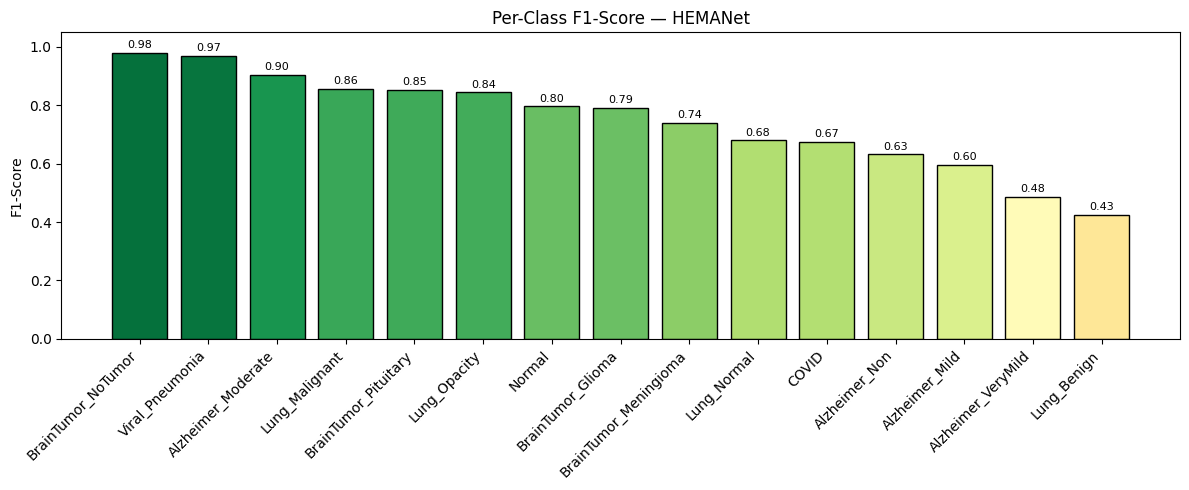


Saved F1 chart: Research_Paper_Outputs/Graphs/per_class_f1.png


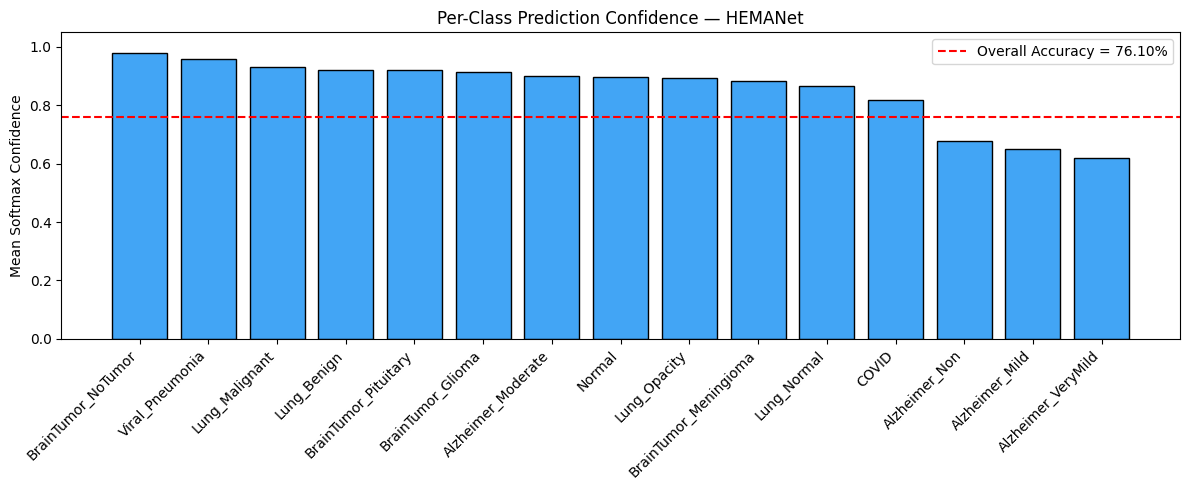

Saved confidence chart: Research_Paper_Outputs/Graphs/per_class_confidence.png

McNemar's Test (HEMANet vs Backbone-Only):
  Statistic : 15.4631
  p-value   : 0.000084
  → Statistically SIGNIFICANT improvement (p < 0.05) ✓

Saved stats report: Research_Paper_Outputs/statistical_analysis.txt

HEMANet — Statistical Analysis Report
Overall Accuracy  : 76.10%
95% CI (Wilson)   : [72.87%, 79.07%]
Cohen's Kappa     : 0.7436
Macro F1-Score    : 0.7483
Weighted F1-Score : 0.7599
 
McNemar Test (HEMANet vs Backbone-Only):
  Chi² Statistic  : 15.4631
  p-value         : 0.000084
  Significant     : Yes (p < 0.05)
 
Per-Class F1-Scores:
                Class  F1-Score
   BrainTumor_NoTumor  0.980000
      Viral_Pneumonia  0.969697
   Alzheimer_Moderate  0.903846
       Lung_Malignant  0.857143
 BrainTumor_Pituitary  0.851485
         Lung_Opacity  0.844037
               Normal  0.796117
    BrainTumor_Glioma  0.791209
BrainTumor_Meningioma  0.740741
          Lung_Normal  0.679612
              

In [30]:
# ============================================================
# STATISTICAL ANALYSIS
# ============================================================
# Covers:
#   1. Per-class confidence (mean softmax probability)
#   2. 95% Confidence Interval on overall accuracy
#   3. McNemar's Test  (HEMANet vs best baseline)
#   4. Per-class F1-score bar chart
#   5. Kappa score
# ============================================================
 
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    f1_score
)
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
 
# ============================================================
# GENERATE FRESH PREDICTIONS FROM HEMANet
# ============================================================
val_generator.reset()
predictions_stat = model.predict(val_generator, verbose=1)
y_pred_stat      = np.argmax(predictions_stat, axis=1)
y_true_stat      = val_generator.classes
N                = len(y_true_stat)
 
# ============================================================
# 1. OVERALL ACCURACY + 95% CONFIDENCE INTERVAL
# ============================================================
correct    = np.sum(y_pred_stat == y_true_stat)
acc_stat   = correct / N
# Wilson interval
z          = 1.96
lower_ci   = (acc_stat + z**2/(2*N) - z*np.sqrt((acc_stat*(1-acc_stat) + z**2/(4*N))/N)) \
             / (1 + z**2/N)
upper_ci   = (acc_stat + z**2/(2*N) + z*np.sqrt((acc_stat*(1-acc_stat) + z**2/(4*N))/N)) \
             / (1 + z**2/N)
 
print("="*55)
print("STATISTICAL ANALYSIS — HEMANet")
print("="*55)
print(f"\nOverall Accuracy  : {acc_stat*100:.2f}%")
print(f"95% CI (Wilson)   : [{lower_ci*100:.2f}%, {upper_ci*100:.2f}%]")
 
# ============================================================
# 2. COHEN'S KAPPA
# ============================================================
kappa = cohen_kappa_score(y_true_stat, y_pred_stat)
print(f"Cohen's Kappa     : {kappa:.4f}  ({'substantial' if kappa > 0.6 else 'moderate'})")
 
# ============================================================
# 3. PER-CLASS CONFIDENCE (mean max softmax probability)
# ============================================================
per_class_conf = {}
for cls_idx, cls_name in enumerate(class_names):
    mask = (y_true_stat == cls_idx)
    if mask.sum() > 0:
        per_class_conf[cls_name] = float(
            np.mean(np.max(predictions_stat[mask], axis=1))
        )
 
conf_df = pd.DataFrame.from_dict(
    per_class_conf, orient='index', columns=["Mean Confidence"]
).reset_index().rename(columns={"index": "Class"})
conf_df = conf_df.sort_values("Mean Confidence", ascending=False)
 
print("\nPer-Class Mean Confidence:")
print(conf_df.to_string(index=False))
 
# ============================================================
# 4. PER-CLASS F1-SCORE BAR CHART
# ============================================================
f1_scores = f1_score(y_true_stat, y_pred_stat, average=None)
f1_df     = pd.DataFrame({"Class": class_names, "F1-Score": f1_scores})
f1_df     = f1_df.sort_values("F1-Score", ascending=False)
 
plt.figure(figsize=(12, 5))
colors_f1 = plt.cm.RdYlGn(f1_df["F1-Score"].values)
bars = plt.bar(f1_df["Class"], f1_df["F1-Score"], color=colors_f1, edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.ylabel("F1-Score")
plt.title("Per-Class F1-Score — HEMANet")
for bar, val in zip(bars, f1_df["F1-Score"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
f1_chart = os.path.join(GRAPH_DIR, "per_class_f1.png")
plt.savefig(f1_chart)
plt.show()
print(f"\nSaved F1 chart: {f1_chart}")
 
# ============================================================
# 5. MEAN CONFIDENCE PER CLASS CHART
# ============================================================
plt.figure(figsize=(12, 5))
plt.bar(conf_df["Class"], conf_df["Mean Confidence"],
        color="#42A5F5", edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.ylabel("Mean Softmax Confidence")
plt.title("Per-Class Prediction Confidence — HEMANet")
plt.axhline(y=acc_stat, color='red', linestyle='--',
            label=f"Overall Accuracy = {acc_stat*100:.2f}%")
plt.legend()
plt.tight_layout()
conf_chart = os.path.join(GRAPH_DIR, "per_class_confidence.png")
plt.savefig(conf_chart)
plt.show()
print(f"Saved confidence chart: {conf_chart}")
 
# ============================================================
# 6. McNEMAR'S TEST  (HEMANet vs VGG16 — use Variant A as proxy
#    if you haven't stored VGG16 predictions separately)
# ============================================================
#  We compare HEMANet vs Ablation Variant A (backbone only)
#  using the models already evaluated above.
 
val_generator.reset()
preds_a_stat = _m_a.predict(val_generator, verbose=0)
y_pred_a     = np.argmax(preds_a_stat, axis=1)
 
correct_hema = (y_pred_stat == y_true_stat).astype(int)
correct_a    = (y_pred_a   == y_true_stat).astype(int)
 
# Contingency table: [both right, hema right/a wrong],
#                    [hema wrong/a right, both wrong]
b = np.sum((correct_hema == 1) & (correct_a == 0))
c = np.sum((correct_hema == 0) & (correct_a == 1))
 
table = np.array([[np.sum((correct_hema == 1) & (correct_a == 1)),  b],
                  [c, np.sum((correct_hema == 0) & (correct_a == 0))]])
 
result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's Test (HEMANet vs Backbone-Only):")
print(f"  Statistic : {result.statistic:.4f}")
print(f"  p-value   : {result.pvalue:.6f}")
if result.pvalue < 0.05:
    print("  → Statistically SIGNIFICANT improvement (p < 0.05) ✓")
else:
    print("  → Difference NOT statistically significant (p ≥ 0.05)")
 
# ============================================================
# 7. SAVE FULL STATS REPORT
# ============================================================
stats_report = f"""
HEMANet — Statistical Analysis Report
{'='*50}
Overall Accuracy  : {acc_stat*100:.2f}%
95% CI (Wilson)   : [{lower_ci*100:.2f}%, {upper_ci*100:.2f}%]
Cohen's Kappa     : {kappa:.4f}
Macro F1-Score    : {f1_score(y_true_stat, y_pred_stat, average='macro'):.4f}
Weighted F1-Score : {f1_score(y_true_stat, y_pred_stat, average='weighted'):.4f}
 
McNemar Test (HEMANet vs Backbone-Only):
  Chi² Statistic  : {result.statistic:.4f}
  p-value         : {result.pvalue:.6f}
  Significant     : {'Yes (p < 0.05)' if result.pvalue < 0.05 else 'No'}
 
Per-Class F1-Scores:
{f1_df.to_string(index=False)}
 
Per-Class Confidence:
{conf_df.to_string(index=False)}
"""
 
stats_path = os.path.join(OUTPUT_DIR, "statistical_analysis.txt")
with open(stats_path, "w") as f:
    f.write(stats_report)
print(f"\nSaved stats report: {stats_path}")
print(stats_report)